# 🧠 Notebook 3: Fine-Tuning CNN-Transformer untuk Lokalisasi PVC/VT
## Integrasi 1D-CGAN Data Augmentation, Grid Search Tuning, dan Multi-Scale Attention

**Pipeline Penelitian (Sesuai Proposal TA & Validasi Berbasis Pasien):**
Notebook ini mengimplementasikan alur Fine-Tuning komprehensif untuk mengoptimasi model lokalisasi PVC/VT berbasis sinyal EKG 12-lead:

```
DATA DWT 12-LEAD -> SPLIT 80/20 (Patient-Level)
  -> 1D-CGAN Data Augmentation (Menyeimbangkan kelas minoritas pada 80% train)
  -> 5-Fold Stratified Group K-Fold Cross Validation (Grid Search Hyperparameter Tuning)
  -> 3 Model CNN-Transformer Disempurnakan:
      1. CNN-Transformer Encoder (Global Temporal Attention + Attention Pooling)
      2. CNN-PatchTST (Patch Tokenization + Attention Pooling)
      3. CNN-Hierarchical Transformer (Multi-Scale Fusion Mikro QRS & Makro Irama)
  -> Final Retraining (Seluruh 80% data latih dengan Best Config per model)
  -> Final Inference pada 20% Unseen Test Set (Patient-Wise Soft Probability Averaging)
  -> Supplementary Analysis (Summit & Unknown sublocation)
  -> Interpretasi Keputusan Fitur Sadapan (SHAP Explainability)
```

---
## 1. Import Library & Konfigurasi Global

**Proses Sel ini:**
1. Mengimpor library deep learning (PyTorch), manipulasi data (pandas, numpy), visualisasi (matplotlib, seaborn), dan metrik medis (scikit-learn).
2. Mengatur random seed (`SEED = 42`) untuk menjamin keterulangan (*reproducibility*) eksperimen.
3. Mendeteksi hardware acceleration (mps / cuda / cpu).
4. Menetapkan konfigurasi dasar model (12 sadapan, segmen 5000 sampel, 5-fold CV, 3 kelas target).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, time, json, math, copy, warnings
import itertools
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"✅ PyTorch {torch.__version__} | Device: {DEVICE}")

plt.rcParams.update({
    'figure.figsize': (16, 8), 'figure.dpi': 100, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'axes.grid': True, 'grid.alpha': 0.3,
})

BASE_DIR = Path('.')
PREPROCESSED_DIR = BASE_DIR / 'preprocessed_data'
DWT_DIR = PREPROCESSED_DIR / 'dwt_denoised'
OUTPUT_DIR = BASE_DIR / 'finetune_results'
OUTPUT_DIR.mkdir(exist_ok=True)

# Kelas target utama: 3 kelas
CLASS_NAMES = ['LVOT', 'Non-OT', 'RVOT']
N_CLASSES = len(CLASS_NAMES)

# Fixed Configs (Sisanya akan di-tune via Grid Search)
CONFIG = {
    'segment_length': 5000, 'sampling_rate': 1000, 'n_leads': 12,
    'n_classes': N_CLASSES,
    'n_folds': 5, 'epochs': 50,
    'patience': 10,
    'cnn_channels': [32, 64, 128, 256], 'cnn_kernels': [7, 5, 3, 3],
    'transformer_heads': 4, 'transformer_layers': 2,
    'fc_dropout': 0.3, 'patch_size': 16,
}

LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
MODEL_NAMES = ['Transformer Encoder', 'PatchTST', 'Hierarchical Transformer']
MODEL_COLORS = ['#2563EB', '#DC2626', '#059669']

# Mapping Sublocation
RVOT_SUBS = ['PosteriorSeptal', 'AnteriorSeptal', 'FreeWall', 'RVOTOther']
LVOT_SUBS = ['LCC', 'RCC', 'AMC', 'LCC-RCC Ommisure']
NONOT_SUBS = ['LC', 'AC', 'RC']
LV_NONOT_SUBS = ['Summit']

print(f"\n📋 Fixed Konfigurasi:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")
print(f"\n🏷️ Kelas Target ({N_CLASSES}): {CLASS_NAMES}")

✅ PyTorch 2.12.0 | Device: mps

📋 Fixed Konfigurasi:
   segment_length: 5000
   sampling_rate: 1000
   n_leads: 12
   n_classes: 3
   n_folds: 5
   epochs: 50
   patience: 10
   cnn_channels: [32, 64, 128, 256]
   cnn_kernels: [7, 5, 3, 3]
   transformer_heads: 4
   transformer_layers: 2
   fc_dropout: 0.3
   patch_size: 16

🏷️ Kelas Target (3): ['LVOT', 'Non-OT', 'RVOT']


---
## 2. Load Data (Mapping 3 Kelas + Supplementary Groups)

**Proses Sel ini:**
1. Memuat metadata pemisahan pasien (`train_ids.npy` dan `test_ids.npy`) yang membagi data menjadi 80% train (230 pasien) dan 20% test (59 pasien) secara *patient-level* (mencegah data leakage segmen pasien).
2. Memetakan sublokasi anatomis ke **3 Kelas Utama**:
   * **RVOT**: PosteriorSeptal, AnteriorSeptal, FreeWall, RVOTOther
   * **LVOT**: LCC, RCC, AMC, LCC-RCC Ommisure
   * **Non-OT**: LC, AC, RC
3. Mengisolasi kelompok **Supplementary**:
   * `LV Non-OT` (Summit, 5 pasien)
   * `Unknown Sublocation` (NaN, 40 pasien) untuk evaluasi eksploratif terpisah.
4. Menginisialisasi `LabelEncoder` dan dictionary pemetaan sublokasi per pasien.

In [2]:
split_meta = pd.read_csv(PREPROCESSED_DIR / 'split_metadata.csv')
train_ids = np.load(PREPROCESSED_DIR / 'train_ids.npy', allow_pickle=True)
test_ids = np.load(PREPROCESSED_DIR / 'test_ids.npy', allow_pickle=True)
df_diag = pd.read_excel(BASE_DIR / 'Diagnosis.xlsx')

def map_classes(row):
    sub = row['Sublocation']
    if pd.isna(sub): return None
    if sub in RVOT_SUBS: return 'RVOT'
    if sub in LVOT_SUBS: return 'LVOT'
    if sub in NONOT_SUBS: return 'Non-OT'
    if sub in LV_NONOT_SUBS: return 'LV Non-OT'
    return None

df_diag['Class'] = df_diag.apply(map_classes, axis=1)

# Pisahkan data utama (3 kelas) dan supplementary
df_main = df_diag[df_diag['Class'].isin(CLASS_NAMES)].reset_index(drop=True)
df_suppl_summit = df_diag[df_diag['Class'] == 'LV Non-OT'].reset_index(drop=True)
df_suppl_nan = df_diag[df_diag['Class'].isna()].reset_index(drop=True)
n_dropped = df_diag['Class'].isna().sum()

# LabelEncoder untuk 3 kelas
le = LabelEncoder()
le.fit(CLASS_NAMES)

# Filter train/test IDs untuk eksperimen utama
main_ids_str = set(df_main['HospitalID'].astype(str).values)
train_ids_main = np.array([x for x in train_ids if str(x) in main_ids_str])
test_ids_main = np.array([x for x in test_ids if str(x) in main_ids_str])

# ID untuk supplementary
suppl_ids_summit = df_suppl_summit['HospitalID'].values
suppl_ids_nan = df_suppl_nan['HospitalID'].values
suppl_ids = suppl_ids_summit  # backward compat untuk segmentasi awal

# Mapping sublocation per pasien (untuk analisis per-sublocation)
patient_sublocation = {}
for _, row in df_diag.iterrows():
    patient_sublocation[row['HospitalID']] = row['Sublocation'] if pd.notna(row['Sublocation']) else 'Unknown'

print("=" * 70)
print("📂 DATA LOADED — 3 KELAS LOKALISASI PVC")
print("=" * 70)
print(f"   Total pasien awal       : {len(df_diag)}")
print(f"   Eksperimen Utama (3 cls): {len(df_main)} pasien")
print(f"   Training (80%)          : {len(train_ids_main)} pasien")
print(f"   Testing  (20%)          : {len(test_ids_main)} pasien")
print(f"   Supplementary Summit    : {len(suppl_ids_summit)} pasien")
print(f"   Supplementary Unknown   : {len(suppl_ids_nan)} pasien")

📂 DATA LOADED — 3 KELAS LOKALISASI PVC
   Total pasien awal       : 334
   Eksperimen Utama (3 cls): 289 pasien
   Training (80%)          : 230 pasien
   Testing  (20%)          : 59 pasien
   Supplementary Summit    : 5 pasien
   Supplementary Unknown   : 40 pasien


---
## 3. Preprocessing — Segmentation & Normalisasi Sinyal

**Proses Sel ini:**
1. **Pemuatan Sinyal EKG DWT**: Memuat rekaman 12-lead yang telah dide-noise dengan Discrete Wavelet Transform (DWT) untuk mereduksi baseline wander dan noise frekuensi tinggi.
2. **Segmentasi Jendela Geser (Sliding Window)**:
   * Memecah rekaman kontinu menjadi segmen-segmen sepanjang 5000 sampel (10 detik pada 500 Hz).
   * Menerapkan overlap 50% untuk memperkaya representasi temporal dan menjaga kontinuitas gelombang PVC.
3. **Normalisasi `StandardScaler`**:
   * Parameter mean dan varians dihitung (*fit*) secara ketat **hanya pada 80% data latih**.
   * Parameter training tersebut kemudian digunakan untuk mentransformasi data test dan data supplementary (mencegah data leakage).
4. **Visualisasi Distribusi Awal**: Memplot komposisi jumlah segmen dan proporsi tiap kelas sebelum proses augmentasi.

⏳ Loading DWT denoised signals (training)...
   ✅ Loaded 230 signals from Train 80% (DWT)
⏳ Loading DWT denoised signals (testing)...
   ✅ Loaded 59 signals from Test 20% (DWT)
⏳ Loading DWT denoised signals (supplementary Summit)...
   ✅ Loaded 5 signals from Supplementary Summit (DWT)
⏳ Loading DWT denoised signals (supplementary Unknown)...
   ✅ Loaded 40 signals from Supplementary Unknown (DWT)

⏳ Segmentasi sinyal (Overlap 50%)...

⏳ Normalisasi (StandardScaler fit on training)...


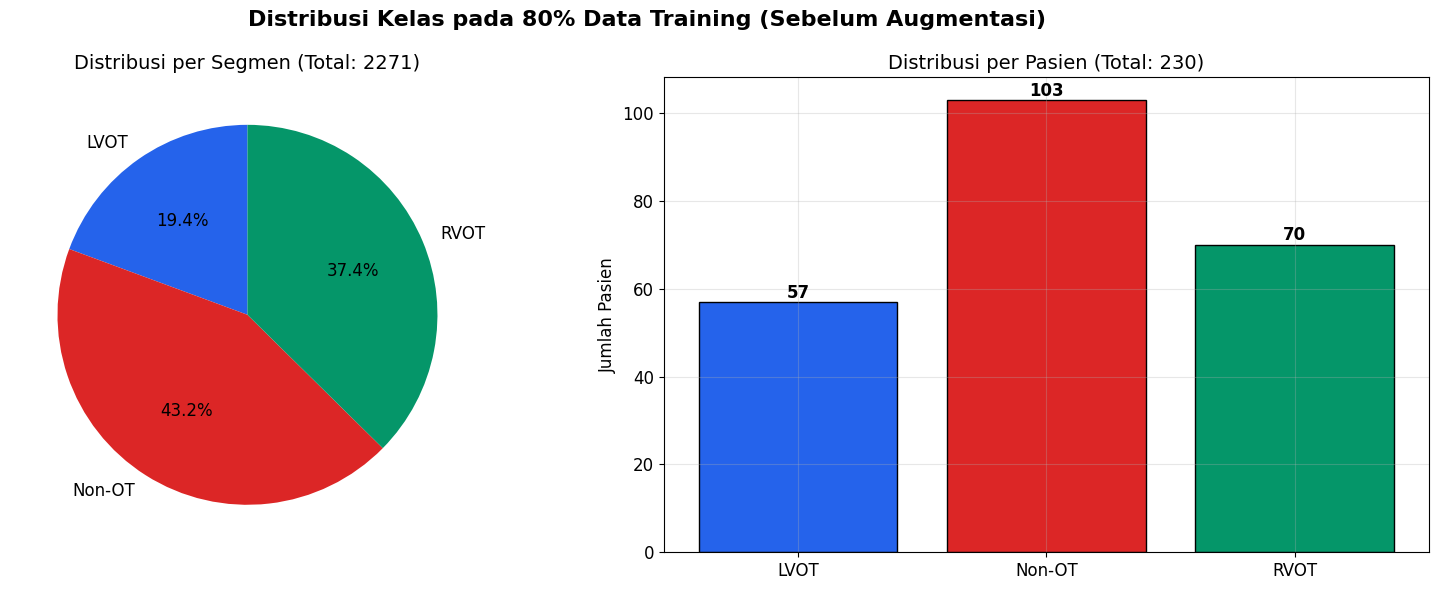

In [3]:
def load_ecg_signals(hospital_ids, ecg_dir, source_name=""):
    signals, errors = {}, []
    for hid in hospital_ids:
        try:
            df = pd.read_csv(ecg_dir / f"{hid}.csv")
            signals[hid] = df[LEADS].values
        except Exception as e:
            errors.append((hid, str(e)))
    if errors:
        print(f"   ⚠️ {len(errors)} errors loading {source_name}")
    print(f"   ✅ Loaded {len(signals)} signals from {source_name}")
    return signals

def segment_signals(signals, labels_dict, segment_length=5000, overlap=0.5):
    X_list, y_list, group_list = [], [], []
    step = int(segment_length * (1 - overlap))
    for hid, signal in signals.items():
        if hid not in labels_dict:
            continue
        n_samples = len(signal)
        label = labels_dict[hid]
        if n_samples < segment_length:
            padded = np.zeros((segment_length, signal.shape[1]))
            padded[:n_samples] = signal
            X_list.append(padded.T)
            y_list.append(label)
            group_list.append(hid)
        else:
            start = 0
            while start + segment_length <= n_samples:
                segment = signal[start:start + segment_length]
                X_list.append(segment.T)
                y_list.append(label)
                group_list.append(hid)
                start += step
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(group_list)

print("⏳ Loading DWT denoised signals (training)...")
train_signals = load_ecg_signals(train_ids_main, DWT_DIR, "Train 80% (DWT)")
print("⏳ Loading DWT denoised signals (testing)...")
test_signals = load_ecg_signals(test_ids_main, DWT_DIR, "Test 20% (DWT)")
print("⏳ Loading DWT denoised signals (supplementary Summit)...")
suppl_signals_summit = load_ecg_signals(suppl_ids_summit, DWT_DIR, "Supplementary Summit (DWT)")
print("⏳ Loading DWT denoised signals (supplementary Unknown)...")
suppl_signals_nan = load_ecg_signals(suppl_ids_nan, DWT_DIR, "Supplementary Unknown (DWT)")

label_dict_main = {}
for _, row in df_main.iterrows():
    label_dict_main[row['HospitalID']] = le.transform([row['Class']])[0]

print("\n⏳ Segmentasi sinyal (Overlap 50%)...")
X_train_all, y_train_all, groups_train = segment_signals(train_signals, label_dict_main, CONFIG['segment_length'])
X_test_all, y_test_all, groups_test = segment_signals(test_signals, label_dict_main, CONFIG['segment_length'])
suppl_label_dict_summit = {hid: -1 for hid in suppl_ids_summit}
X_suppl_summit, _, groups_suppl_summit = segment_signals(suppl_signals_summit, suppl_label_dict_summit, CONFIG['segment_length'])
suppl_label_dict_nan = {hid: -1 for hid in suppl_ids_nan}
X_suppl_nan, _, groups_suppl_nan = segment_signals(suppl_signals_nan, suppl_label_dict_nan, CONFIG['segment_length'])

# Backward compat
X_suppl_all = X_suppl_summit
groups_suppl = groups_suppl_summit

print("\n⏳ Normalisasi (StandardScaler fit on training)...")
n_seg, n_leads, seg_len = X_train_all.shape
X_flat = X_train_all.transpose(0, 2, 1).reshape(-1, n_leads)
scaler = StandardScaler()
scaler.fit(X_flat)

X_train_scaled = scaler.transform(X_flat).reshape(n_seg, seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)
X_test_flat = X_test_all.transpose(0, 2, 1).reshape(-1, n_leads)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test_all.shape[0], seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)

# Scale supplementary Summit
if len(X_suppl_summit) > 0:
    X_suppl_summit_flat = X_suppl_summit.transpose(0, 2, 1).reshape(-1, n_leads)
    X_suppl_summit_scaled = scaler.transform(X_suppl_summit_flat).reshape(X_suppl_summit.shape[0], seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)
else:
    X_suppl_summit_scaled = np.array([], dtype=np.float32)

# Scale supplementary Unknown
if len(X_suppl_nan) > 0:
    X_suppl_nan_flat = X_suppl_nan.transpose(0, 2, 1).reshape(-1, n_leads)
    X_suppl_nan_scaled = scaler.transform(X_suppl_nan_flat).reshape(X_suppl_nan.shape[0], seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)
else:
    X_suppl_nan_scaled = np.array([], dtype=np.float32)

# Backward compat
X_suppl_scaled = X_suppl_summit_scaled

# Visualisasi Distribusi Kelas sebelum Augmentasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Kelas pada 80% Data Training (Sebelum Augmentasi)', fontsize=16, fontweight='bold')

# Pie chart per segmen
train_counts = np.bincount(y_train_all, minlength=N_CLASSES)
axes[0].pie(train_counts, labels=le.classes_, autopct='%1.1f%%', colors=MODEL_COLORS, startangle=90, textprops={'fontsize': 12})
axes[0].set_title(f'Distribusi per Segmen (Total: {len(y_train_all)})', fontsize=14)

# Bar chart per pasien
patient_classes = []
for hid in np.unique(groups_train):
    patient_classes.append(label_dict_main[hid])
pat_counts = np.bincount(patient_classes, minlength=N_CLASSES)
axes[1].bar(le.classes_, pat_counts, color=MODEL_COLORS, edgecolor='black')
axes[1].set_title(f'Distribusi per Pasien (Total: {len(np.unique(groups_train))})', fontsize=14)
axes[1].set_ylabel('Jumlah Pasien')
for i, v in enumerate(pat_counts):
    axes[1].text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'distribusi_kelas_pre_augmentasi.png'), dpi=150, bbox_inches='tight')
plt.show(block=False)
plt.close()

---
## 4. GAN Architecture & Training (Augmentasi Data)

**Proses Sel ini:**
1. **Arsitektur 1D-CGAN (Conditional GAN)**:
   * **`Generator1D`**: Menerima vektor laten acak $z \sim \mathcal{N}(0, 1)$ dan label kelas kondisional, lalu membangkitkan sinyal EKG sintetik 12-lead (panjang 5000 sampel) melalui blok konvolusi transpose 1D dan aktivasi LeakyReLU.
   * **`Discriminator1D`**: Menerima sinyal EKG 12-lead beserta label kondisional untuk membedakan sinyal real vs sintetik.
2. **Pelatihan Adversarial (50 Epochs)**:
   * Dilatih menggunakan Binary Cross-Entropy Loss dengan label smoothing (real: 0.9, fake: 0.1) untuk menstabilkan konvergensi GAN.
3. **Pembangkitan Sinyal Sintetik untuk Penyeimbangan Kelas**:
   * Menghasilkan sampel sintetik pada kelas minoritas (LVOT dan RVOT) hingga menyamai jumlah kelas mayoritas (Non-OT).
4. **Visualisasi Validasi Sinyal Sintetik**:
   * Memplot kurva loss Generator vs Discriminator (`gan_loss_curves.png`).
   * Menampilkan perbandingan distribusi kelas sebelum vs sesudah augmentasi (`distribusi_kelas_post_augmentasi.png`).
   * Menampilkan visualisasi overlay 12-lead EKG nyata vs sintetik (`real_vs_synthetic_ecg.png`).

🤖 TRAINING 1D-CGAN (50 Epochs)
   [Epoch 1/50] | D loss: 0.5502 | G loss: 0.8985
   [Epoch 10/50] | D loss: 0.3290 | G loss: 2.0054
   [Epoch 20/50] | D loss: 0.3268 | G loss: 2.0690
   [Epoch 30/50] | D loss: 0.3255 | G loss: 2.0800
   [Epoch 40/50] | D loss: 0.3257 | G loss: 2.0796
   [Epoch 50/50] | D loss: 0.3256 | G loss: 2.0729

⏳ Generating Synthetic Data...
✅ Generated 675 synthetic segments.


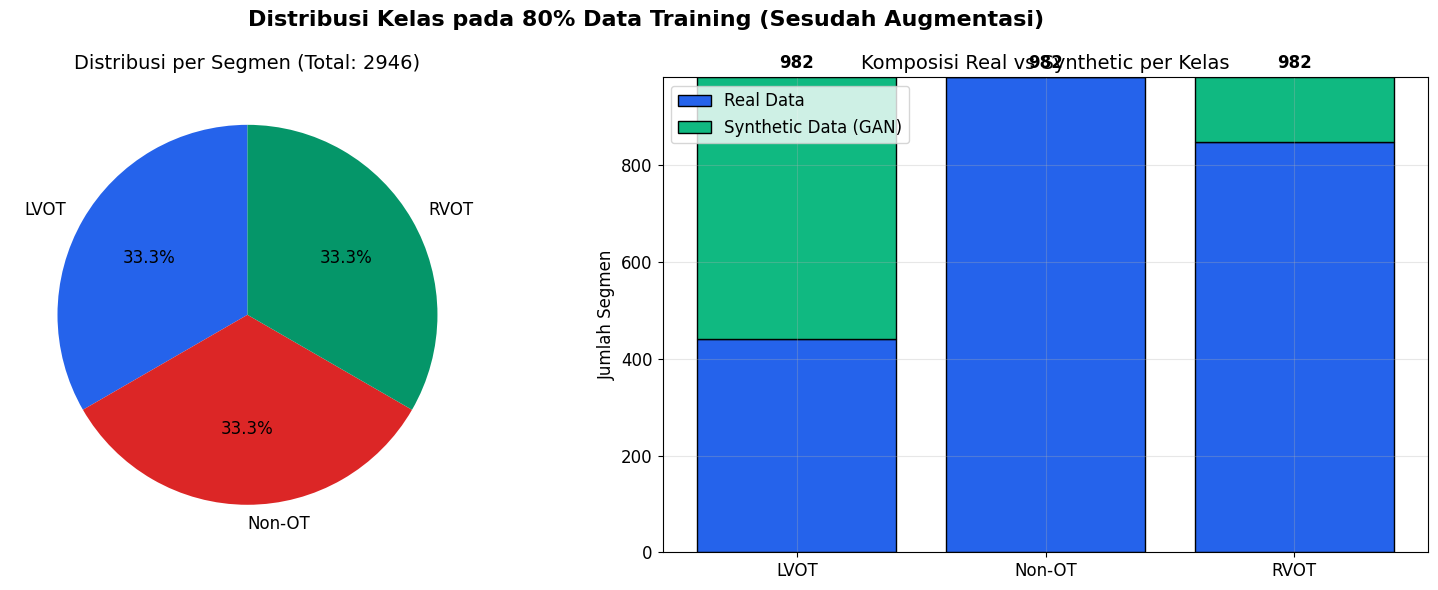

In [4]:
class Generator1D(nn.Module):
    def __init__(self, latent_dim=100, embed_dim=50, num_classes=3, out_channels=12, seq_length=5000):
        super().__init__()
        self.seq_length = seq_length
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        self.init_size = 312
        self.l1 = nn.Sequential(nn.Linear(latent_dim + embed_dim, 256 * self.init_size))
        
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm1d(256),
            nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose1d(32, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
        
    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], -1)
        out = self.l1(x)
        out = out.view(out.shape[0], 256, self.init_size)
        out = self.conv_blocks(out)
        
        # Resize to exactly seq_length (5000)
        out = F.interpolate(out, size=self.seq_length, mode='linear', align_corners=False)
        return out

class Discriminator1D(nn.Module):
    def __init__(self, num_classes=3, embed_dim=50, in_channels=12, seq_length=5000):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        self.model = nn.Sequential(
            nn.Conv1d(in_channels + embed_dim, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv1d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        c = self.label_emb(labels)
        c = c.unsqueeze(2).expand(-1, -1, img.size(2))
        x = torch.cat([img, c], 1)
        out = self.model(x)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# Inisialisasi GAN
latent_dim = 100
generator = Generator1D(latent_dim=latent_dim, num_classes=N_CLASSES).to(DEVICE)
discriminator = Discriminator1D(num_classes=N_CLASSES).to(DEVICE)

# Loss & Optimizers
adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Dataset untuk GAN Training (hanya menggunakan 80% data)
gan_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train_all))
gan_loader = DataLoader(gan_dataset, batch_size=64, shuffle=True)

# Training Loop GAN
n_epochs_gan = 50 # Diperkecil menjadi 50 epochs untuk efisiensi komputasi
print("=" * 70)
print(f"🤖 TRAINING 1D-CGAN ({n_epochs_gan} Epochs)")
print("=" * 70)

g_losses, d_losses = [], []
for epoch in range(n_epochs_gan):
    g_loss_ep, d_loss_ep = 0, 0
    
    for i, (imgs, labels) in enumerate(gan_loader):
        batch_size = imgs.size(0)
        
        # Real & Fake labels with label smoothing
        valid = torch.FloatTensor(batch_size, 1).fill_(0.9).to(DEVICE)
        fake = torch.FloatTensor(batch_size, 1).fill_(0.1).to(DEVICE)
        
        real_imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Train Generator
        optimizer_G.zero_grad()
        z = torch.FloatTensor(np.random.normal(0, 1, (batch_size, latent_dim))).to(DEVICE)
        gen_imgs = generator(z, labels)
        g_loss = adversarial_loss(discriminator(gen_imgs, labels), valid)
        g_loss.backward()
        optimizer_G.step()
        
        # Train Discriminator
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(real_imgs, labels), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), labels), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()
        
        g_loss_ep += g_loss.item()
        d_loss_ep += d_loss.item()
        
    g_losses.append(g_loss_ep / len(gan_loader))
    d_losses.append(d_loss_ep / len(gan_loader))
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"   [Epoch {epoch+1}/{n_epochs_gan}] | D loss: {d_losses[-1]:.4f} | G loss: {g_losses[-1]:.4f}")

# Plot GAN Training Curves
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss', color='blue')
plt.plot(d_losses, label='Discriminator Loss', color='red')
plt.title('GAN Training Loss Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(str(OUTPUT_DIR / 'gan_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.close()

# Generate Synthetic Data untuk Balancing
target_count = max(train_counts)
synthetic_X, synthetic_y = [], []
print("\n⏳ Generating Synthetic Data...")

generator.eval()
with torch.no_grad():
    for cls_idx in range(N_CLASSES):
        count = train_counts[cls_idx]
        if count < target_count:
            needed = target_count - count
            # Generate in batches
            batch_size = 64
            n_batches = int(np.ceil(needed / batch_size))
            
            for _ in range(n_batches):
                curr_b = min(batch_size, needed)
                z = torch.FloatTensor(np.random.normal(0, 1, (curr_b, latent_dim))).to(DEVICE)
                labels = torch.LongTensor([cls_idx] * curr_b).to(DEVICE)
                gen_imgs = generator(z, labels).cpu().numpy()
                synthetic_X.extend(gen_imgs)
                synthetic_y.extend([cls_idx] * curr_b)
                needed -= curr_b

synthetic_X = np.array(synthetic_X, dtype=np.float32)
synthetic_y = np.array(synthetic_y)
synthetic_groups = np.array(['SYNTHETIC'] * len(synthetic_y))

print(f"✅ Generated {len(synthetic_X)} synthetic segments.")

# Gabungkan Real + Synthetic Data
X_train_aug = np.concatenate([X_train_scaled, synthetic_X], axis=0)
y_train_aug = np.concatenate([y_train_all, synthetic_y], axis=0)
groups_train_aug = np.concatenate([groups_train, synthetic_groups], axis=0)

aug_counts = np.bincount(y_train_aug, minlength=N_CLASSES)

# Plot Kelas Sesudah Augmentasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribusi Kelas pada 80% Data Training (Sesudah Augmentasi)', fontsize=16, fontweight='bold')

axes[0].pie(aug_counts, labels=le.classes_, autopct='%1.1f%%', colors=MODEL_COLORS, startangle=90, textprops={'fontsize': 12})
axes[0].set_title(f'Distribusi per Segmen (Total: {len(y_train_aug)})', fontsize=14)

# Real vs Synthetic Bar Chart
real_counts = np.bincount(y_train_all, minlength=N_CLASSES)
syn_counts = np.bincount(synthetic_y, minlength=N_CLASSES) if len(synthetic_y) > 0 else np.zeros(N_CLASSES)

axes[1].bar(le.classes_, real_counts, label='Real Data', color='#2563EB', edgecolor='black')
axes[1].bar(le.classes_, syn_counts, bottom=real_counts, label='Synthetic Data (GAN)', color='#10B981', edgecolor='black')
axes[1].set_title('Komposisi Real vs Synthetic per Kelas', fontsize=14)
axes[1].set_ylabel('Jumlah Segmen')
axes[1].legend()

for i, (r, s) in enumerate(zip(real_counts, syn_counts)):
    axes[1].text(i, r + s + 10, f'{r+s}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'distribusi_kelas_post_augmentasi.png'), dpi=150, bbox_inches='tight')
plt.show(block=False)
plt.close()

# Visualisasi Sample ECG: Real vs Synthetic
if len(synthetic_X) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle('Real vs Synthetic ECG Signals (Overlay 12-Leads)', fontsize=16, fontweight='bold', y=0.92)
    
    for i, cls_idx in enumerate(range(N_CLASSES)):
        ax = axes[i]
        
        # Get 1 random real sample
        real_idx = np.where(y_train_all == cls_idx)[0]
        real_sample = X_train_scaled[real_idx[0]]
        
        # Get 1 random synthetic sample
        syn_idx = np.where(synthetic_y == cls_idx)[0]
        if len(syn_idx) > 0:
            syn_sample = synthetic_X[syn_idx[0]]
            
            # Plot Real (Blue) and Synthetic (Orange) - offset leads
            t = np.arange(5000) / 1000
            for lead in range(12):
                offset = lead * 5
                ax.plot(t, real_sample[lead, :] + offset, color='#2563EB', alpha=0.7, linewidth=0.8, 
                        label='Real' if lead == 0 else "")
                ax.plot(t, syn_sample[lead, :] + offset, color='#F59E0B', alpha=0.7, linewidth=0.8,
                        label='Synthetic' if lead == 0 else "")
            
            ax.set_title(f'Class: {le.classes_[cls_idx]}', fontsize=12)
            ax.set_yticks(np.arange(0, 12*5, 5))
            ax.set_yticklabels(LEADS)
            ax.set_xlabel('Time (s)')
            if i == 0:
                ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'real_vs_synthetic_ecg.png'), dpi=150, bbox_inches='tight')
    plt.close()

---
## 5. Model Architectures & Training/Evaluation Functions (Patient-Wise)

**Proses Sel ini:**
1. **Arsitektur Feature Extractor & Tiga Varian Transformer Disempurnakan**:
   * **`CNNFeatureExtractor`**: 4 blok konvolusi 1D (32, 64, 128, 256 channel) untuk mengekstraksi morfologi lokal gelombang P-QRS-T.
   * **`AttentionPooling`**: Lapisan atensi dinamis yang memberi bobot tinggi pada gelombang PVC abnormal dan meredam segmen isoelektrik/normal.
   * **`CNNTransformerEncoder`**: Pemodelan dependensi global sekuens waktu + Attention Pooling.
   * **`CNNPatchTST`**: Tokenisasi patch lokal-global + Attention Pooling untuk menangani redundansi time-series.
   * **`CNNHierarchicalTransformer` (Proposal Hal. 24)**: Representasi multi-skala (Level 1 mikro-morfologi QRS + Level 2 makro-irama) yang disatukan melalui *Multi-Scale Feature Fusion*.
2. **Fungsi Pelatihan (`train_one_epoch`)**:
   * Menjalankan feedforward, komputasi loss, backward pass, dan gradient clipping (`max_norm=1.0`).
3. **Fungsi Evaluasi Pasien (`evaluate_patient_wise`)**:
   * Menggunakan **Soft Probability Averaging** ($\hat{y}_{	ext{patient}} = rg\max 
rac{1}{M} \sum P(y \mid 	ext{segmen}_m)$). Segmen yang memuat gelombang PVC dengan keyakinan tinggi secara akurat mendominasi keputusan pasien.

In [5]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=12, channels=[32, 64, 128, 256], kernels=[7, 5, 3, 3]):
        super().__init__()
        layers = []
        prev_ch = in_channels
        for ch, k in zip(channels, kernels):
            layers.extend([
                nn.Conv1d(prev_ch, ch, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(ch),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2, stride=2),
            ])
            prev_ch = ch
        self.features = nn.Sequential(*layers)
        self.out_channels = channels[-1]

    def forward(self, x):
        return self.features(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class AttentionPooling(nn.Module):
    """
    Attention-based pooling layer to dynamically weight time/patch steps.
    Emphasizes PVC morphological spikes and suppresses baseline/sinus noise.
    """
    def __init__(self, d_model):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.Tanh(),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        pooled = (x * weights).sum(dim=1)
        return pooled

class CNNTransformerEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        self.pos_enc = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['transformer_layers'])
        self.attn_pool = AttentionPooling(d_model)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, config['n_classes']))

    def forward(self, x):
        features = self.cnn(x)
        features = features.permute(0, 2, 1)
        features = self.pos_enc(features)
        features = self.transformer(features)
        pooled = self.attn_pool(features)
        return self.classifier(pooled)

class CNNPatchTST(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.patch_size = config['patch_size']
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        self.patch_proj = nn.Linear(self.patch_size * d_model, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['transformer_layers'])
        self.attn_pool = AttentionPooling(d_model)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, config['n_classes']))

    def forward(self, x):
        features = self.cnn(x)
        features = features.permute(0, 2, 1)
        B, S, D = features.shape
        n_patches = S // self.patch_size
        features = features[:, :n_patches * self.patch_size, :]
        patches = features.reshape(B, n_patches, self.patch_size * D)
        patches = self.patch_proj(patches)
        patches = self.pos_enc(patches)
        patches = self.transformer(patches)
        pooled = self.attn_pool(patches)
        return self.classifier(pooled)

class CNNHierarchicalTransformer(nn.Module):
    """
    Hierarchical Transformer based on Tang et al. (2024) and Proposal TA (p. 24):
    Scale 1: Local micro-morphology (detailed PVC deflection patterns)
    Scale 2: Global rhythm context (downsampled sequence)
    Multi-Scale Fusion: Attn_hierarchical = sum_{s in scales} alpha_s * MHSA(Z_s)
    """
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        
        # Scale 1: Local micro-morphology
        self.pos_enc_1 = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        enc_layer_1 = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer_level1 = nn.TransformerEncoder(enc_layer_1, num_layers=1)
        self.attn_pool_1 = AttentionPooling(d_model)

        # Downsample to Scale 2
        self.downsample = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True))

        # Scale 2: Global rhythm context
        self.pos_enc_2 = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        enc_layer_2 = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer_level2 = nn.TransformerEncoder(enc_layer_2, num_layers=1)
        self.attn_pool_2 = AttentionPooling(d_model)

        # Multi-Scale Fusion: Combines Scale 1 (Local) and Scale 2 (Global)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout'])
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, config['n_classes']))

    def forward(self, x):
        features = self.cnn(x)
        seq = features.permute(0, 2, 1)
        
        # Scale 1: Local
        seq = self.pos_enc_1(seq)
        local_out = self.transformer_level1(seq)
        v1 = self.attn_pool_1(local_out)
        
        # Scale 2: Global
        ds = local_out.permute(0, 2, 1)
        ds = self.downsample(ds)
        ds = ds.permute(0, 2, 1)
        ds = self.pos_enc_2(ds)
        global_out = self.transformer_level2(ds)
        v2 = self.attn_pool_2(global_out)
        
        # Multi-scale fusion
        fused = self.fusion(torch.cat([v1, v2], dim=-1))
        return self.classifier(fused)

class ECGDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y) if y is not None else None
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        if self.y is not None: return self.X[idx], self.y[idx]
        return self.X[idx]

def compute_metrics(y_true, y_pred, y_prob, n_classes=3):
    acc = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    specificities = []
    for i in range(n_classes):
        tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    specificity = np.mean(specificities)
    
    try:
        if y_prob.ndim == 2 and y_prob.shape[1] == n_classes:
            auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        else:
            auc = 0.0
    except Exception:
        auc = 0.0
    
    return {'accuracy': acc, 'sensitivity': sensitivity, 'specificity': specificity, 'f1': f1, 'auc': auc}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct += out.argmax(1).eq(y_b).sum().item()
        total += len(y_b)
    return total_loss / total, correct / total

def evaluate_patient_wise(model, loader, groups_val, device, n_classes=3):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            out = model(X_b)
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_b.numpy())
            
    patient_preds_dict, patient_probs_dict, patient_true_dict = {}, {}, {}
    for i, hid in enumerate(groups_val):
        if hid not in patient_preds_dict:
            patient_preds_dict[hid] = []
            patient_probs_dict[hid] = []
            patient_true_dict[hid] = all_labels[i]
        patient_preds_dict[hid].append(all_preds[i])
        patient_probs_dict[hid].append(all_probs[i])
        
    y_true_pat, y_pred_pat, y_prob_pat = [], [], []
    for hid in patient_preds_dict:
        y_true_pat.append(patient_true_dict[hid])
        # Soft Probability Averaging (Bayesian expectation over patient segments)
        mean_p = np.mean(patient_probs_dict[hid], axis=0)
        y_prob_pat.append(mean_p)
        y_pred_pat.append(int(mean_p.argmax()))
        
    y_true_pat = np.array(y_true_pat)
    y_pred_pat = np.array(y_pred_pat)
    y_prob_pat = np.array(y_prob_pat)
    
    metrics = compute_metrics(y_true_pat, y_pred_pat, y_prob_pat, n_classes)
    return metrics, y_true_pat, y_pred_pat, y_prob_pat

# Class weights (dari real data counts)
class_weights = 1.0 / (real_counts + 1e-8)
class_weights = class_weights / class_weights.sum() * N_CLASSES
class_weights = torch.FloatTensor(class_weights)

---
## 6. Grid Search Hyperparameter Tuning (5-Fold CV Patient-Wise)

**Proses Sel ini:**
1. **Metodologi Validasi Silang Berbasis Pasien**:
   * Menggunakan `StratifiedGroupKFold` (5 Fold) pada data latih 80% dengan pengelompokan `groups_train` (HospitalID), memastikan tidak ada segmen dari pasien yang sama yang berada di train dan validation sekaligus.
2. **Eksplorasi Kombinasi Hyperparameter**:
   * Menguji kandidat konfigurasi terarah (`learning_rate`, `batch_size`, `transformer_dropout`, `weight_decay`) pada ketiga model.
   * Menerapkan `CosineAnnealingLR` scheduler dan `Label Smoothing Cross-Entropy (0.05)` pada setiap fold.
3. **Pemilihan Konfigurasi Terbaik (Model Selection)**:
   * Memilih kombinasi yang menghasilkan nilai **Mean Patient-Wise Macro-F1** tertinggi di 5 fold.
   * Menyimpan median best epoch dari fold-fold validasi untuk digunakan pada pelatihan final.

🔍 GRID SEARCH TUNING — 36 KOMBINASI PER MODEL
⚠️ Menjalankan 3 kombinasi terarah untuk efisiensi...

══════════════════════════════════════════════════════════════════════
🧠 TUNING MODEL: Transformer Encoder
══════════════════════════════════════════════════════════════════════

   [Config 1/3] {'learning_rate': 0.0003, 'batch_size': 32, 'transformer_dropout': 0.2, 'weight_decay': 0.0001}
      Fold 1: Best F1=0.617 di Epoch 1
      Fold 2: Best F1=0.708 di Epoch 2
      Fold 3: Best F1=0.615 di Epoch 5
      Fold 4: Best F1=0.648 di Epoch 22
      Fold 5: Best F1=0.610 di Epoch 13
   => Mean F1: 0.640 | Median Best Epoch: 5

   [Config 2/3] {'learning_rate': 0.0001, 'batch_size': 16, 'transformer_dropout': 0.3, 'weight_decay': 0.0001}
      Fold 1: Best F1=0.610 di Epoch 4
      Fold 2: Best F1=0.755 di Epoch 6
      Fold 3: Best F1=0.688 di Epoch 2
      Fold 4: Best F1=0.561 di Epoch 12
      Fold 5: Best F1=0.647 di Epoch 2
   => Mean F1: 0.652 | Median Best Epoch: 4

   [Config 3/

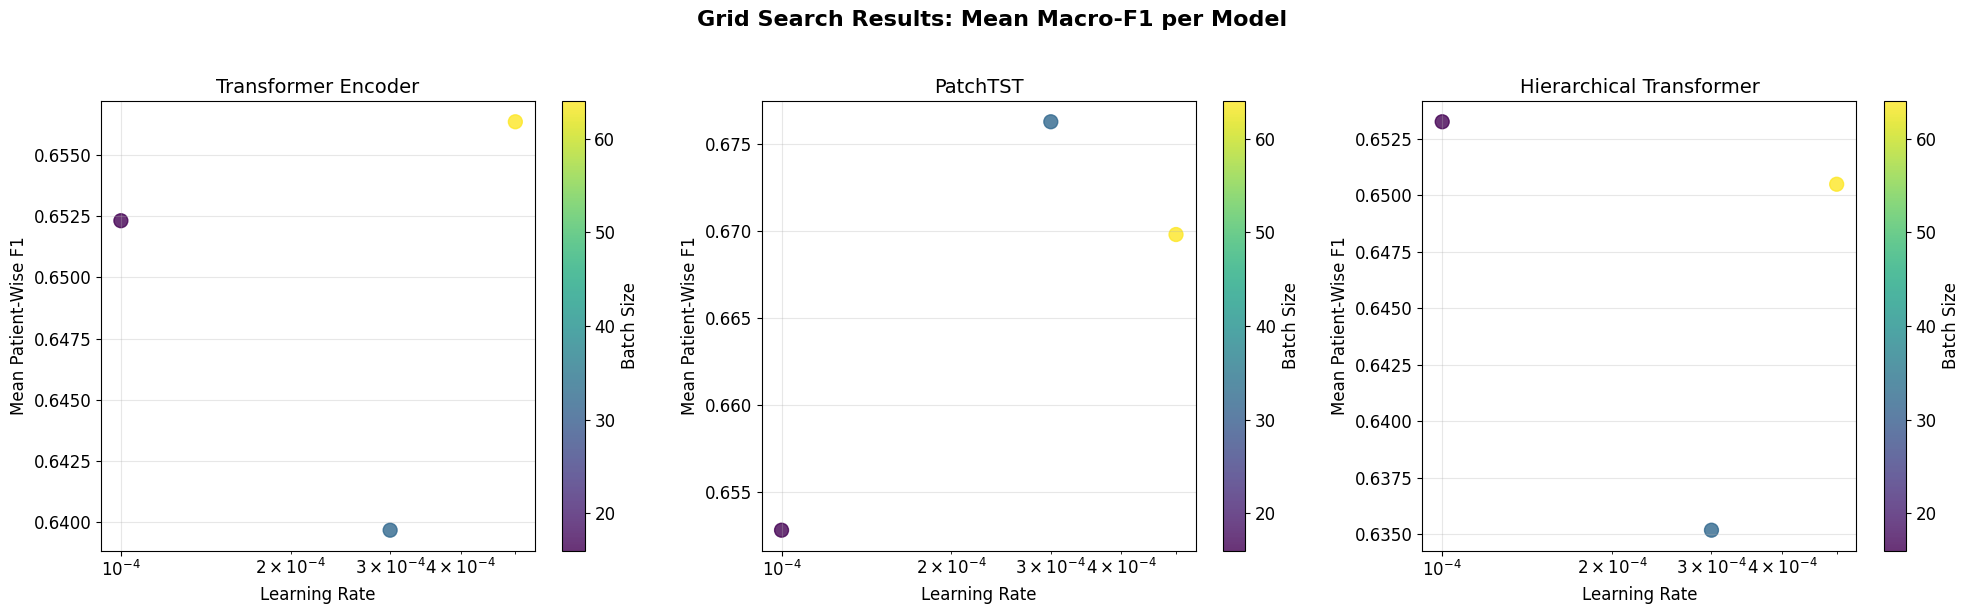

In [6]:
grid_params = {
    'learning_rate': [1e-4, 3e-4, 5e-4],
    'batch_size': [16, 32, 64],
    'transformer_dropout': [0.2, 0.3],
    'weight_decay': [1e-5, 1e-4]
}

keys, values = zip(*grid_params.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
print("=" * 70)
print(f"🔍 GRID SEARCH TUNING — {len(param_combinations)} KOMBINASI PER MODEL")
print("=" * 70)

skgf = StratifiedGroupKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)
model_classes = [CNNTransformerEncoder, CNNPatchTST, CNNHierarchicalTransformer]

# Set 3 kombinasi representatif beragam untuk mengevaluasi semua model
subset_params = [
    {'learning_rate': 3e-4, 'batch_size': 32, 'transformer_dropout': 0.2, 'weight_decay': 1e-4},
    {'learning_rate': 1e-4, 'batch_size': 16, 'transformer_dropout': 0.3, 'weight_decay': 1e-4},
    {'learning_rate': 5e-4, 'batch_size': 64, 'transformer_dropout': 0.2, 'weight_decay': 1e-5}
]

print(f"⚠️ Menjalankan {len(subset_params)} kombinasi terarah untuk efisiensi...")

best_configs = {}

for model_name, ModelClass in zip(MODEL_NAMES, model_classes):
    print(f"\n{'═'*70}")
    print(f"🧠 TUNING MODEL: {model_name}")
    print(f"{'═'*70}")
    
    best_f1_model = 0
    best_config_model = None
    best_epoch_median = 0
    best_model_fold_histories = []
    
    all_config_results = []
    
    for c_idx, params in enumerate(subset_params):
        print(f"\n   [Config {c_idx+1}/{len(subset_params)}] {params}")
        
        # Update config
        curr_config = copy.deepcopy(CONFIG)
        curr_config.update(params)
        
        fold_f1s = []
        fold_best_epochs = []
        fold_histories = []
        
        for fold, (train_idx, val_idx) in enumerate(skgf.split(X_train_scaled, y_train_all, groups_train)):
            # Pisahkan data Real (training vs validation)
            X_ft_real, y_ft_real = X_train_scaled[train_idx], y_train_all[train_idx]
            X_fv, y_fv, grp_fv = X_train_scaled[val_idx], y_train_all[val_idx], groups_train[val_idx]
            
            # Tambahkan Synthetic ke Training
            X_ft = np.concatenate([X_ft_real, synthetic_X], axis=0)
            y_ft = np.concatenate([y_ft_real, synthetic_y], axis=0)
            
            train_loader = DataLoader(ECGDataset(X_ft, y_ft), batch_size=curr_config['batch_size'], shuffle=True, drop_last=True)
            val_loader = DataLoader(ECGDataset(X_fv, y_fv), batch_size=curr_config['batch_size'], shuffle=False)
            
            model = ModelClass(curr_config).to(DEVICE)
            criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
            optimizer = optim.AdamW(model.parameters(), lr=curr_config['learning_rate'], weight_decay=curr_config['weight_decay'])
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=curr_config['epochs'], eta_min=1e-6)
            
            best_val_f1, patience_cnt, best_ep = 0, 0, 0
            history = {'train_acc': [], 'val_acc': []}
            
            for epoch in range(curr_config['epochs']):
                tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
                scheduler.step()
                val_m, _, _, _ = evaluate_patient_wise(model, val_loader, grp_fv, DEVICE, N_CLASSES)
                history['train_acc'].append(tr_acc)
                history['val_acc'].append(val_m['accuracy'])
                
                if val_m['f1'] > best_val_f1:
                    best_val_f1 = val_m['f1']
                    patience_cnt = 0
                    best_ep = epoch + 1
                else:
                    patience_cnt += 1
                    if patience_cnt >= curr_config['patience']:
                        break
            
            fold_f1s.append(best_val_f1)
            fold_best_epochs.append(best_ep)
            fold_histories.append(history)
            print(f"      Fold {fold+1}: Best F1={best_val_f1:.3f} di Epoch {best_ep}")
            
        mean_f1 = np.mean(fold_f1s)
        median_ep = int(np.median(fold_best_epochs))
        print(f"   => Mean F1: {mean_f1:.3f} | Median Best Epoch: {median_ep}")
        
        all_config_results.append({
            'params': params,
            'mean_f1': mean_f1,
            'median_epoch': median_ep
        })
        
        if mean_f1 > best_f1_model:
            best_f1_model = mean_f1
            best_config_model = params
            best_epoch_median = median_ep
            best_model_fold_histories = fold_histories
            
    best_configs[model_name] = {
        'params': best_config_model,
        'median_epoch': best_epoch_median,
        'best_f1': best_f1_model,
        'all_results': all_config_results,
        'histories': best_model_fold_histories
    }
    
    print(f"\n🏆 Best Config for {model_name}: {best_config_model} (F1: {best_f1_model:.3f})")

# Visualisasi Top Configs
print("\n📊 Membuat Scatter Plot Grid Search...")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Grid Search Results: Mean Macro-F1 per Model', fontsize=16, fontweight='bold', y=1.02)

for i, model_name in enumerate(MODEL_NAMES):
    res = best_configs[model_name]['all_results']
    lrs = [r['params']['learning_rate'] for r in res]
    f1s = [r['mean_f1'] for r in res]
    bzs = [r['params']['batch_size'] for r in res]
    
    ax = axes[i]
    scatter = ax.scatter(lrs, f1s, c=bzs, cmap='viridis', s=100, alpha=0.8)
    ax.set_xscale('log')
    ax.set_title(model_name)
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Mean Patient-Wise F1')
    plt.colorbar(scatter, ax=ax, label='Batch Size')
    
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'grid_search_scatter.png'), dpi=150, bbox_inches='tight')
plt.show(block=False)
plt.close()

### Visualisasi K-Fold Training vs Validation (Best Config)

**Proses Sel ini:**
1. Memplot kurva historis Training Accuracy vs Validation Accuracy per epoch (rata-rata dan standar deviasi across 5 folds).
2. Memvisualisasikan scatter plot hubungan antara learning rate, batch size, dan mean Macro-F1 untuk ketiga model.
3. Menyimpan visualisasi ke  dan .


📊 Membuat Plot K-Fold Training vs Validation (Best Config)...


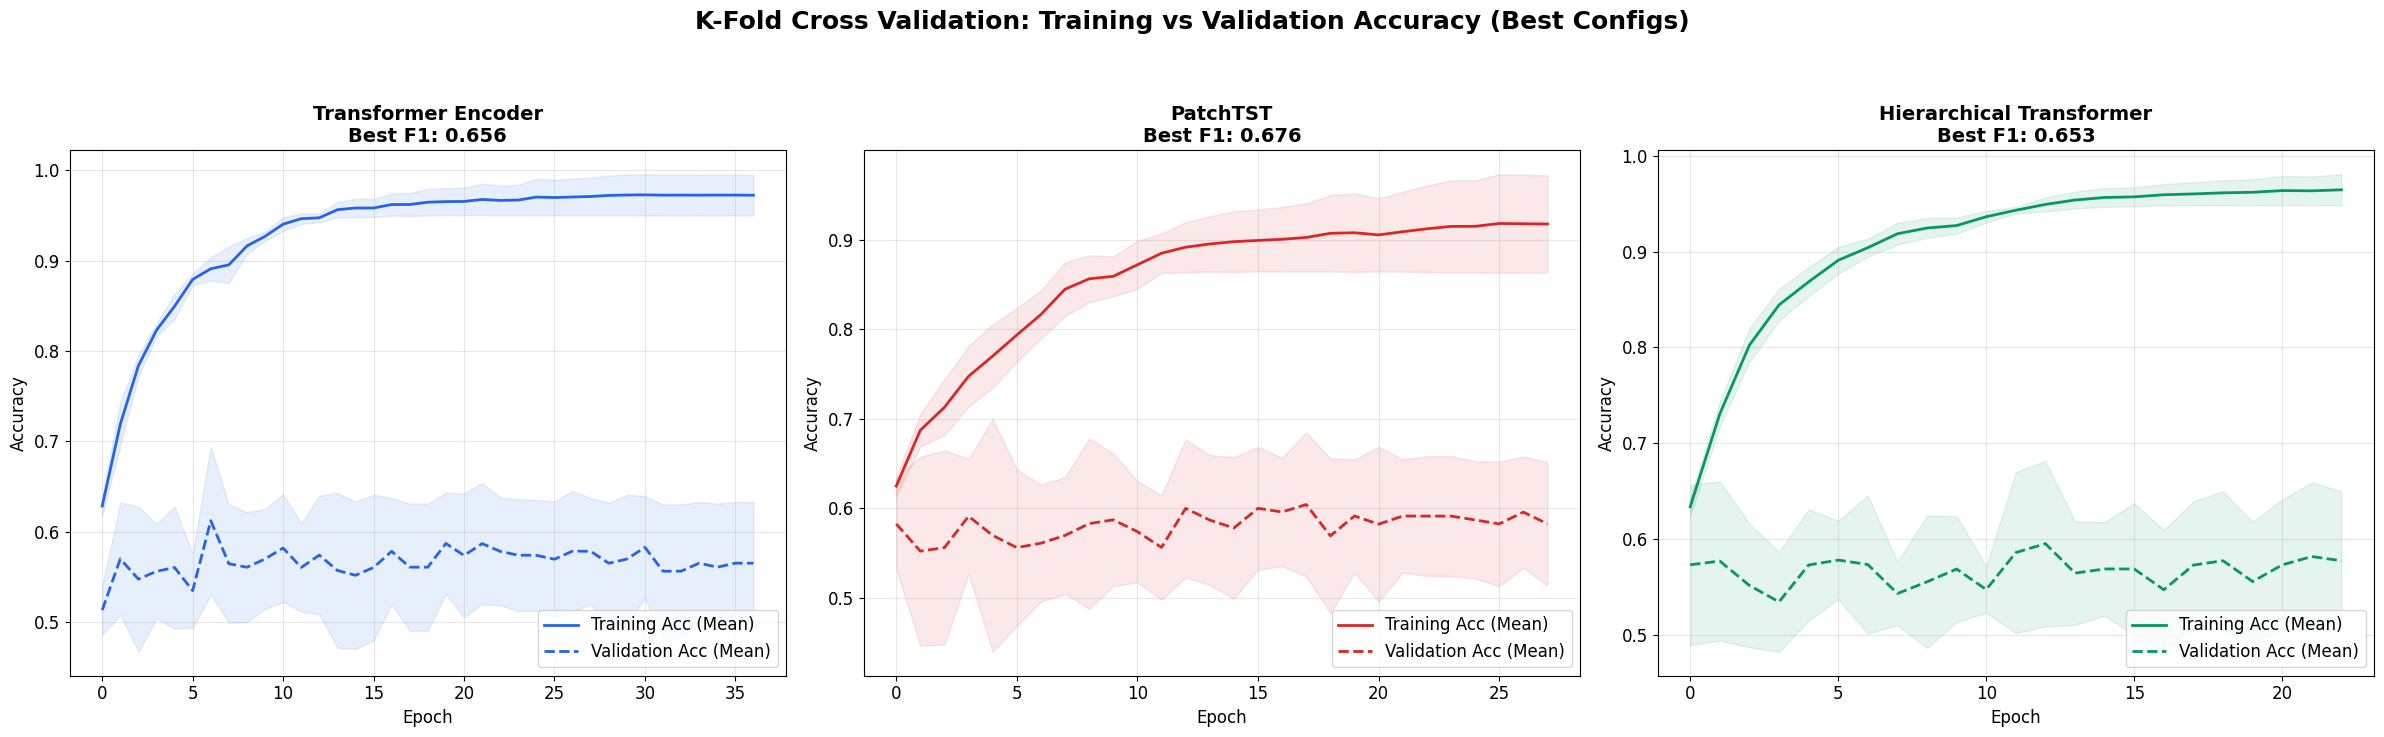

In [7]:
print("\n📊 Membuat Plot K-Fold Training vs Validation (Best Config)...")
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('K-Fold Cross Validation: Training vs Validation Accuracy (Best Configs)',
             fontsize=18, fontweight='bold', y=1.05)

for i, model_name in enumerate(MODEL_NAMES):
    ax = axes[i]
    color = MODEL_COLORS[i]
    histories = best_configs[model_name]['histories']
    max_len = max(len(h['val_acc']) for h in histories)

    train_accs = np.array([h['train_acc'] + [h['train_acc'][-1]]*(max_len - len(h['train_acc'])) for h in histories])
    val_accs = np.array([h['val_acc'] + [h['val_acc'][-1]]*(max_len - len(h['val_acc'])) for h in histories])

    mean_train = np.mean(train_accs, axis=0)
    std_train = np.std(train_accs, axis=0)
    mean_val = np.mean(val_accs, axis=0)
    std_val = np.std(val_accs, axis=0)
    epochs = np.arange(max_len)

    ax.plot(epochs, mean_train, color=color, linewidth=2, label='Training Acc (Mean)', linestyle='-')
    ax.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.1, color=color)

    ax.plot(epochs, mean_val, color=color, linewidth=2, label='Validation Acc (Mean)', linestyle='--')
    ax.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.1, color=color)

    ax.set_title(f'{model_name}\nBest F1: {best_configs[model_name]["best_f1"]:.3f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'grid_search_kfold_curves.png'), dpi=150, bbox_inches='tight')
plt.show(block=False)
plt.close()

---
## 7. Final Model Training — Semua 3 Model (Best Config)

**Proses Sel ini:**
1. Melatih ulang ketiga model dari nol (*from scratch*) menggunakan **seluruh 80% data development pool** (data real + data sintetik GAN).
2. Menerapkan hyperparameter optimal dan durasi pelatihan sejumlah `median_epoch` yang diperoleh dari hasil K-Fold Cross Validation.
3. Menerapkan `CosineAnnealingLR` scheduler untuk memastikan konvergensi bobot yang stabil.
4. Menyimpan bobot model final (`.pth`) ke direktori `finetune_results/`.
5. Memvisualisasikan kurva loss dan akurasi pelatihan model final (`final_training_curves.png`).

🔥 FINAL MODEL TRAINING — SEMUA 3 MODEL (BEST CONFIG)

──────────────────────────────────────────────────
🧠 Transformer Encoder — Target Epochs: 7
   Config: {'learning_rate': 0.0005, 'batch_size': 64, 'transformer_dropout': 0.2, 'weight_decay': 1e-05}
──────────────────────────────────────────────────
   Ep   1/7 | TrLoss 0.6558 | TrAcc 0.627 | 17.6s
   Ep   5/7 | TrLoss 0.3926 | TrAcc 0.861 | 14.9s
   Ep   7/7 | TrLoss 0.3009 | TrAcc 0.922 | 15.0s
   ✅ Model saved!

──────────────────────────────────────────────────
🧠 PatchTST — Target Epochs: 3
   Config: {'learning_rate': 0.0003, 'batch_size': 32, 'transformer_dropout': 0.2, 'weight_decay': 0.0001}
──────────────────────────────────────────────────
   Ep   1/3 | TrLoss 0.6921 | TrAcc 0.596 | 4.9s
   Ep   3/3 | TrLoss 0.5416 | TrAcc 0.743 | 4.7s
   ✅ Model saved!

──────────────────────────────────────────────────
🧠 Hierarchical Transformer — Target Epochs: 6
   Config: {'learning_rate': 0.0001, 'batch_size': 16, 'transformer_dropout

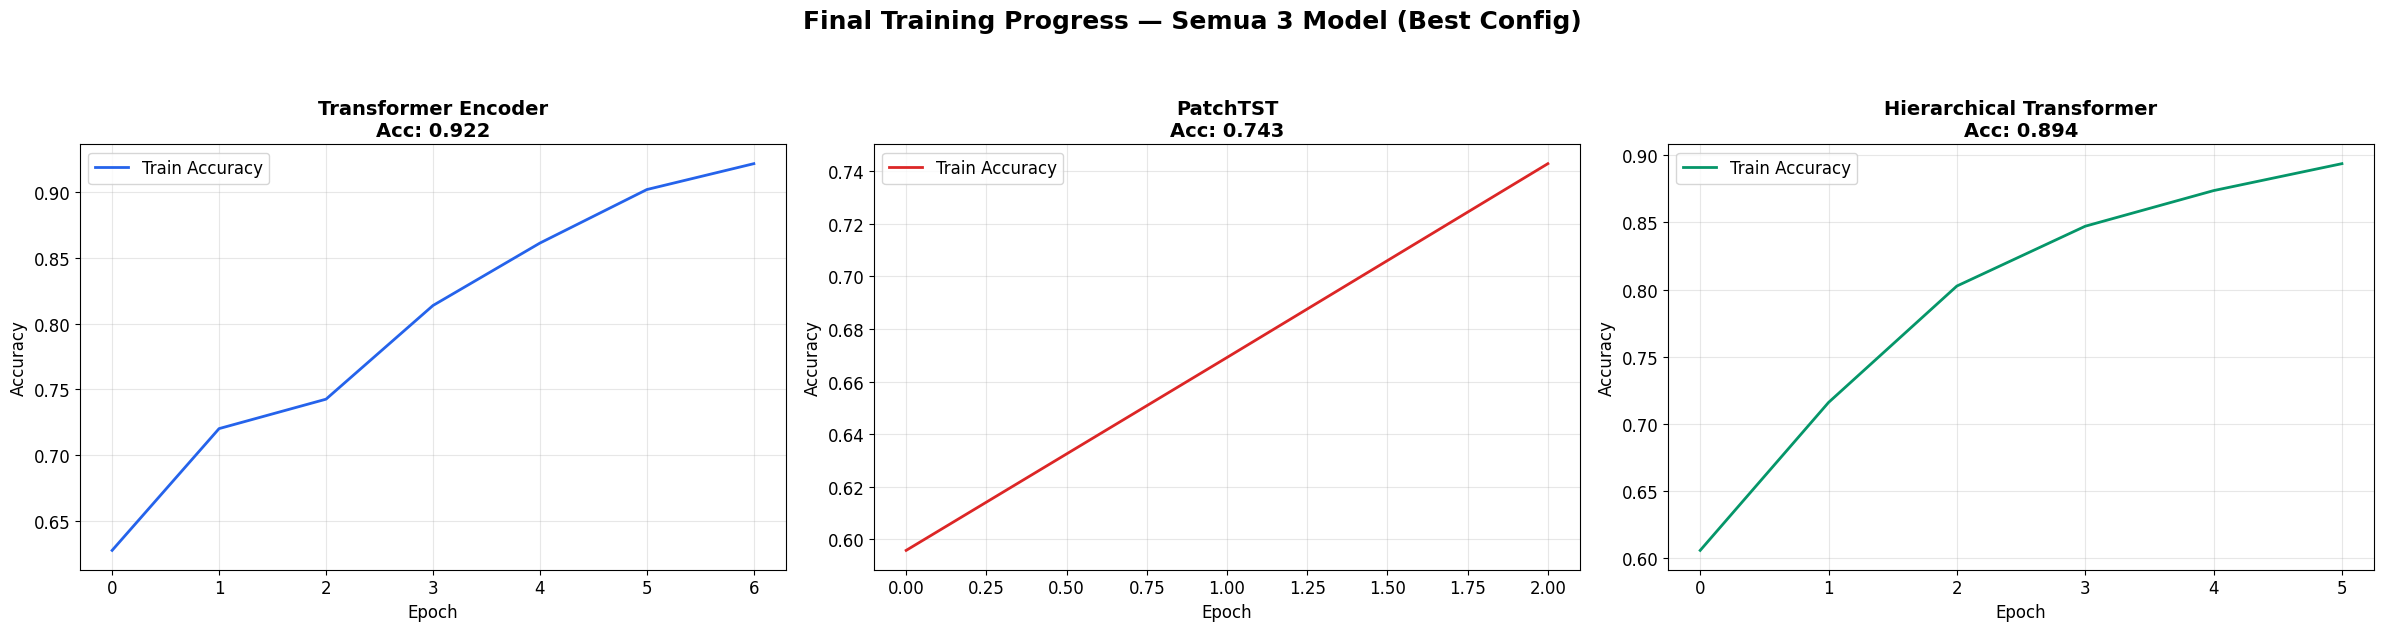

In [8]:
print("=" * 70)
print("🔥 FINAL MODEL TRAINING — SEMUA 3 MODEL (BEST CONFIG)")
print("=" * 70)

# Gabungkan data untuk final training (seluruh 80% real + synthetic)
X_train_final = np.concatenate([X_train_scaled, synthetic_X], axis=0)
y_train_final = np.concatenate([y_train_all, synthetic_y], axis=0)

# Loader will be created dynamically per model below based on best_conf

final_models = {}
final_train_histories = {}

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("Final Training Progress — Semua 3 Model (Best Config)", fontsize=18, fontweight="bold", y=1.05)

for model_idx, (model_name, ModelClass) in enumerate(zip(MODEL_NAMES, model_classes)):
    best_conf = copy.deepcopy(CONFIG)
    best_conf.update(best_configs[model_name]["params"])
    target_epochs = best_configs[model_name]["median_epoch"]
    
    final_train_loader = DataLoader(
        ECGDataset(X_train_final, y_train_final),
        batch_size=best_conf["batch_size"], shuffle=True, drop_last=True)
    
    if target_epochs == 0: target_epochs = 10 # Fallback jika error
    
    print(f"\n{str("─")*50}")
    print(f"🧠 {model_name} — Target Epochs: {target_epochs}")
    print(f"   Config: {best_configs[model_name]["params"]}")
    print(f"{str("─")*50}")

    model = ModelClass(best_conf).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=best_conf["learning_rate"], weight_decay=best_conf["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=target_epochs, eta_min=1e-6)

    history = {"train_loss": [], "train_acc": []}
    for epoch in range(target_epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, final_train_loader, criterion, optimizer, DEVICE)
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == target_epochs - 1:
            print(f"   Ep {epoch+1:3d}/{target_epochs} | TrLoss {tr_loss:.4f} | TrAcc {tr_acc:.3f} | {time.time()-t0:.1f}s")

    final_models[model_name] = model
    final_train_histories[model_name] = history
    
    # Save model
    state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    torch.save(state, OUTPUT_DIR / f"finetuned_{model_name.replace(" ", "_")}.pth")
    print(f"   ✅ Model saved!")
    
    # Plot training curve
    ax = axes[model_idx]
    ax.plot(history["train_acc"], color=MODEL_COLORS[model_idx], label="Train Accuracy", linewidth=2)
    ax.set_title(f"{model_name}\nAcc: {tr_acc:.3f}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "final_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show(block=False)
plt.close()

---
## 8. Final Inference (20% Unseen Test Set) — SEKALI SAJA

**Proses Sel ini:**
1. Mengevaluasi performa model final pada **59 pasien unseen (20% holdout test set)** yang terkunci sejak awal pipeline.
2. Evaluasi dijalankan strictly **sekali saja** menggunakan agregasi *Soft Probability Averaging* pada tingkat pasien.
3. Menghitung metrik performa medis standar:
   * **Accuracy**: Proporsi diagnosis pasien yang tepat.
   * **Sensitivity (Recall Macro)**: Kemampuan mendeteksi masing-masing lokasi PVC.
   * **Specificity**: Kemampuan mengeliminasi lokasi non-target.
   * **Macro F1-Score**: Rata-rata harmonik presisi dan recall penyeimbang antarkelas.
   * **AUC-ROC (One-vs-Rest)**: Daya diskriminasi probabilitas model.
4. Menampilkan Confusion Matrix dan grafik batang performa komparatif ketiga model (`final_inference_results.png`).

🧪 FINAL INFERENCE — 20% UNSEEN TEST (59 Pasien)
   Patient-wise evaluation — SEKALI SAJA

──────────────────────────────────────────────────
🧠 Transformer Encoder
   Patient-Level: Acc=0.576 Sens=0.627 Spec=0.784 F1=0.588 AUC=0.749

──────────────────────────────────────────────────
🧠 PatchTST
   Patient-Level: Acc=0.627 Sens=0.685 Spec=0.808 F1=0.640 AUC=0.805

──────────────────────────────────────────────────
🧠 Hierarchical Transformer
   Patient-Level: Acc=0.712 Sens=0.726 Spec=0.851 F1=0.725 AUC=0.818


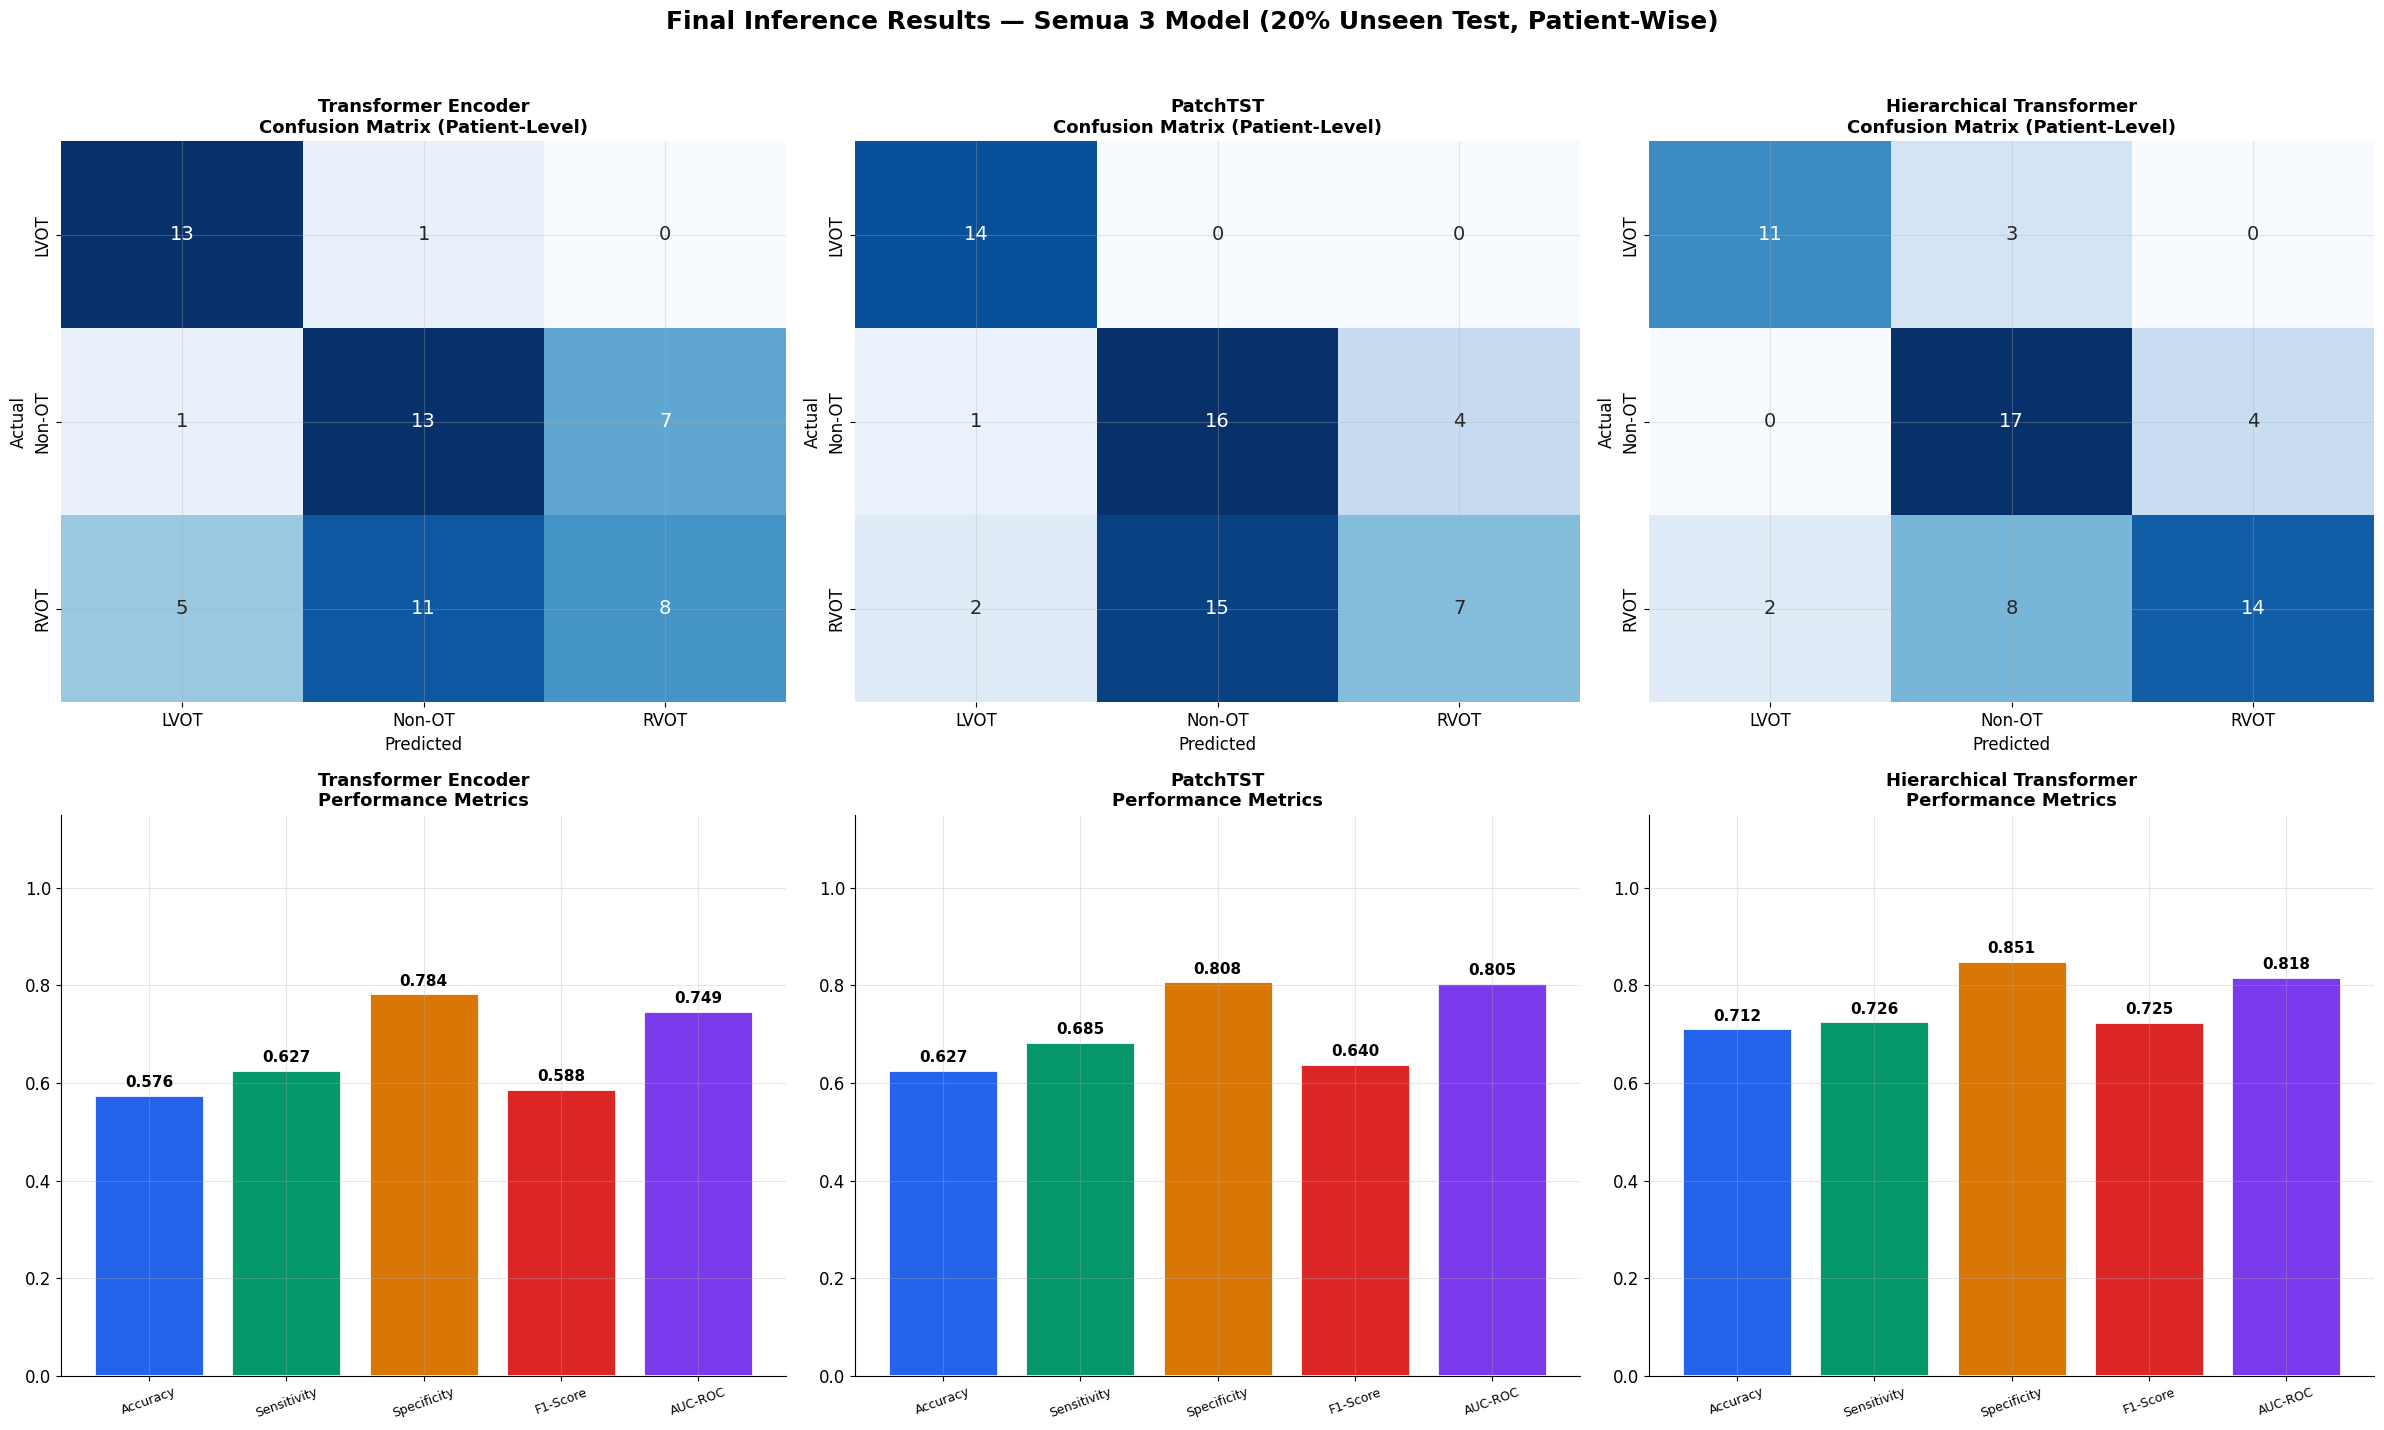


🏆 Best Final Model (by F1): Hierarchical Transformer

📋 Classification Report untuk Model Terbaik (Hierarchical Transformer):
              precision    recall  f1-score   support

        LVOT       0.85      0.79      0.81        14
      Non-OT       0.61      0.81      0.69        21
        RVOT       0.78      0.58      0.67        24

    accuracy                           0.71        59
   macro avg       0.74      0.73      0.73        59
weighted avg       0.73      0.71      0.71        59



In [9]:
print("=" * 70)
print(f"🧪 FINAL INFERENCE — 20% UNSEEN TEST ({len(np.unique(groups_test))} Pasien)")
print(f"   Patient-wise evaluation — SEKALI SAJA")
print("=" * 70)

test_loader = DataLoader(ECGDataset(X_test_scaled, y_test_all), batch_size=64, shuffle=False)

all_final_test = {}

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle("Final Inference Results — Semua 3 Model (20% Unseen Test, Patient-Wise)",
             fontsize=18, fontweight="bold", y=1.02)

for i, model_name in enumerate(MODEL_NAMES):
    model = final_models[model_name]
    
    # Evaluate Patient-wise
    pat_m, y_true_pat, y_pred_pat, y_prob_pat = evaluate_patient_wise(model, test_loader, groups_test, DEVICE, N_CLASSES)
    
    all_final_test[model_name] = {
        "patient_metrics": pat_m,
        "y_true_pat": y_true_pat,
        "y_pred_pat": y_pred_pat,
        "y_prob_pat": y_prob_pat,
    }
    
    print(f"\n{str("─")*50}")
    print(f"🧠 {model_name}")
    print(f"   Patient-Level: Acc={pat_m["accuracy"]:.3f} Sens={pat_m["sensitivity"]:.3f} Spec={pat_m["specificity"]:.3f} F1={pat_m["f1"]:.3f} AUC={pat_m["auc"]:.3f}")
    
    # Confusion Matrix
    ax = axes[0, i]
    cm = confusion_matrix(y_true_pat, y_pred_pat, labels=list(range(N_CLASSES)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"size": 14}, cbar=False)
    ax.set_title(f"{model_name}\nConfusion Matrix (Patient-Level)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    
    # Metrics Bar
    ax = axes[1, i]
    m_names = ["Accuracy", "Sensitivity", "Specificity", "F1-Score", "AUC-ROC"]
    m_keys = ["accuracy", "sensitivity", "specificity", "f1", "auc"]
    m_vals = [pat_m[k] for k in m_keys]
    colors_m = ["#2563EB", "#059669", "#D97706", "#DC2626", "#7C3AED"]
    bars = ax.bar(m_names, m_vals, color=colors_m, edgecolor="white", linewidth=2)
    for bar, val in zip(bars, m_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
    ax.set_title(f"{model_name}\nPerformance Metrics", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    plt.sca(ax)
    plt.xticks(rotation=20, fontsize=9)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "final_inference_results.png"), dpi=150, bbox_inches="tight")
plt.show(block=False)
plt.close()

best_final = max(MODEL_NAMES, key=lambda mn: all_final_test[mn]["patient_metrics"]["f1"])
print(f"\n🏆 Best Final Model (by F1): {best_final}")

# Classification Report untuk Best Model
print(f"\n📋 Classification Report untuk Model Terbaik ({best_final}):")
r_best = all_final_test[best_final]
print(classification_report(r_best["y_true_pat"], r_best["y_pred_pat"], target_names=le.classes_, zero_division=0))

---
## 9. Supplementary Analysis & Per-Sublocation Breakdown

**Proses Sel ini:**
1. **9a. Analisis Pasien LV Non-OT (Summit, 5 Pasien)**:
   * Menjalankan inferensi eksploratif pada pasien Summit menggunakan model terbaik untuk melihat kecenderungan prediksi kemiripan sinyal (LVOT vs Non-OT vs RVOT).
2. **9b. Analisis Pasien Unknown Sublocation (NaN, 40 Pasien)**:
   * Memprediksi lokasi asal PVC untuk 40 pasien yang tidak memiliki label sublokasi di Diagnosis.xlsx, dilengkapi nilai confidence probabilitas per kelas.
3. **9c. Analisis Akurasi Per-Sublokasi Anatomis (Test Set)**:
   * Menganalisis ketepatan klasifikasi model terbaik pada level sublokasi spesifik (RVOT: PosteriorSeptal, AnteriorSeptal, FreeWall; LVOT: LCC, RCC, AMC; Non-OT: LC, AC, RC).
   * Menyimpan rincian ke `per_sublocation_test_results.csv`.

In [10]:
# === Helper: predict per-patient ===
def predict_supplementary(model, X_scaled, groups, device, le, n_classes):
    """Predict patient-wise for supplementary data."""
    loader = DataLoader(ECGDataset(X_scaled), batch_size=64, shuffle=False)
    all_preds, all_probs = [], []
    with torch.no_grad():
        for X_b in loader:
            X_b = X_b.to(device)
            out = model(X_b)
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    patient_preds, patient_probs = {}, {}
    for i, hid in enumerate(groups):
        if hid not in patient_preds:
            patient_preds[hid] = []
            patient_probs[hid] = []
        patient_preds[hid].append(all_preds[i])
        patient_probs[hid].append(all_probs[i])
    
    results = []
    for hid in patient_preds:
        votes = np.array(patient_preds[hid])
        pred_cls_idx = int(np.bincount(votes, minlength=n_classes).argmax())
        pred_cls_name = le.inverse_transform([pred_cls_idx])[0]
        avg_probs = np.mean(patient_probs[hid], axis=0)
        results.append({
            'HospitalID': hid,
            'Predicted': pred_cls_name,
            'Pred_Idx': pred_cls_idx,
            'Probs': avg_probs
        })
    return results

best_final_model = final_models[best_final]
best_final_model.eval()

print("\n" + "=" * 70)
print("🔎 SUPPLEMENTARY ANALYSIS")
print("=" * 70)

# --- 9a. LV Non-OT (Summit) ---
print(f"\n{'─'*70}")
print(f"📌 Grup 1: LV Non-OT (Summit) — {len(suppl_ids_summit)} pasien")
print(f"{'─'*70}")

if len(suppl_ids_summit) == 0:
    print("   Tidak ada data Summit untuk dianalisis.")
else:
    summit_results = predict_supplementary(
        best_final_model, X_suppl_summit_scaled, groups_suppl_summit, DEVICE, le, N_CLASSES)
    
    print(f"Memprediksi {len(summit_results)} pasien Summit menggunakan model {best_final}:")
    print("-" * 60)
    for r in summit_results:
        prob_str = " | ".join([f"{le.classes_[j]}: {r['Probs'][j]:.1%}" for j in range(N_CLASSES)])
        subloc = patient_sublocation.get(r['HospitalID'], 'Unknown')
        print(f"Pasien {str(r['HospitalID']):<7} (Subloc: {subloc:<12}) -> Diprediksi: {r['Predicted']:<10}")
        print(f"  Confidence: {prob_str}")
        print("-" * 60)

# --- 9b. Unknown Sublocation (NaN) ---
print(f"\n{'─'*70}")
print(f"📌 Grup 2: Unknown Sublocation (NaN) — {len(suppl_ids_nan)} pasien")
print(f"{'─'*70}")

if len(X_suppl_nan_scaled) == 0 or len(suppl_ids_nan) == 0:
    print("   Tidak ada data Unknown sublocation untuk dianalisis.")
else:
    nan_results = predict_supplementary(
        best_final_model, X_suppl_nan_scaled, groups_suppl_nan, DEVICE, le, N_CLASSES)
    
    print(f"Memprediksi {len(nan_results)} pasien Unknown menggunakan model {best_final}:")
    print("-" * 60)
    
    # Summary table
    nan_pred_counts = {cls: 0 for cls in CLASS_NAMES}
    for r in nan_results:
        nan_pred_counts[r['Predicted']] += 1
        lr = df_suppl_nan[df_suppl_nan['HospitalID'] == r['HospitalID']]['LeftRight'].values
        lr_str = lr[0] if len(lr) > 0 else '?'
        prob_str = " | ".join([f"{le.classes_[j]}: {r['Probs'][j]:.1%}" for j in range(N_CLASSES)])
        print(f"Pasien {str(r['HospitalID']):<7} (LR: {lr_str:<6}) -> Diprediksi: {r['Predicted']:<10}")
        print(f"  Confidence: {prob_str}")
        print("-" * 60)
    
    print(f"\n📊 Ringkasan Prediksi Unknown Sublocation:")
    for cls, cnt in nan_pred_counts.items():
        pct = cnt / len(nan_results) * 100 if len(nan_results) > 0 else 0
        bar = "█" * int(pct / 2)
        print(f"   {cls:<10}: {cnt:>3} pasien ({pct:>5.1f}%) {bar}")

# --- 9c. Per-Sublocation Breakdown (Test Set, 3 Kelas Utama) ---
print(f"\n{'─'*70}")
print(f"📌 Analisis Per-Sublocation pada Test Set ({len(np.unique(groups_test))} pasien)")
print(f"{'─'*70}")

# Get patient-level predictions from best model test results
test_y_true_pat = r_best["y_true_pat"]
test_y_pred_pat = r_best["y_pred_pat"]
# Order of patients in evaluate_patient_wise preserves appearance in groups_test
seen = set()
ordered_test_patients = [hid for hid in groups_test if not (hid in seen or seen.add(hid))]

# Build patient -> (true_class, pred_class) mapping from test results
test_pat_results = []
for idx, hid in enumerate(ordered_test_patients):
    true_cls = le.inverse_transform([test_y_true_pat[idx]])[0]
    pred_cls = le.inverse_transform([test_y_pred_pat[idx]])[0]
    subloc = patient_sublocation.get(hid, 'Unknown')
    test_pat_results.append({
        'HospitalID': hid,
        'Sublocation': subloc,
        'True_Class': true_cls,
        'Pred_Class': pred_cls,
        'Correct': true_cls == pred_cls
    })

df_subloc_test = pd.DataFrame(test_pat_results)

# Group by sublocation
print(f"\n{'Sublocation':<20} {'Kelas':<10} {'Total':<7} {'Benar':<7} {'Akurasi':<10}")
print("─" * 60)

all_subs_map = {
    'RVOT': RVOT_SUBS,
    'LVOT': LVOT_SUBS,
    'Non-OT': NONOT_SUBS
}

for cls_name, subs_list in all_subs_map.items():
    print(f"\n  ── {cls_name} ──")
    for sub in subs_list:
        df_sub = df_subloc_test[df_subloc_test['Sublocation'] == sub]
        if len(df_sub) == 0:
            print(f"  {sub:<20} {cls_name:<10} {'0':<7} {'-':<7} {'-':<10}")
        else:
            n_correct = df_sub['Correct'].sum()
            n_total = len(df_sub)
            acc = n_correct / n_total
            print(f"  {sub:<20} {cls_name:<10} {n_total:<7} {n_correct:<7} {acc:<10.1%}")

print(f"\n📊 Menyimpan tabel per-sublocation...")
df_subloc_test.to_csv(OUTPUT_DIR / "per_sublocation_test_results.csv", index=False)
print(f"   ✅ Per-sublocation results: {OUTPUT_DIR / 'per_sublocation_test_results.csv'}")


🔎 SUPPLEMENTARY ANALYSIS

──────────────────────────────────────────────────────────────────────
📌 Grup 1: LV Non-OT (Summit) — 5 pasien
──────────────────────────────────────────────────────────────────────
Memprediksi 5 pasien Summit menggunakan model Hierarchical Transformer:
------------------------------------------------------------
Pasien 810713  (Subloc: Summit      ) -> Diprediksi: LVOT      
  Confidence: LVOT: 99.6% | Non-OT: 0.2% | RVOT: 0.2%
------------------------------------------------------------
Pasien 888241  (Subloc: Summit      ) -> Diprediksi: Non-OT    
  Confidence: LVOT: 6.2% | Non-OT: 90.0% | RVOT: 3.8%
------------------------------------------------------------
Pasien 964638  (Subloc: Summit      ) -> Diprediksi: Non-OT    
  Confidence: LVOT: 12.5% | Non-OT: 83.3% | RVOT: 4.2%
------------------------------------------------------------
Pasien 966571  (Subloc: Summit      ) -> Diprediksi: LVOT      
  Confidence: LVOT: 82.5% | Non-OT: 16.1% | RVOT: 1.4%
-

---
## 10. SHAP Explainability (Interpretasi Sadapan EKG)

**Proses Sel ini:**
1. Menggunakan **SHAP (SHapley Additive exPlanations)** via `GradientExplainer` untuk mengukur kontribusi pentingnya masing-masing dari 12 sadapan (leads).
2. Memetakan nilai Shapley pada data uji untuk mengetahui sadapan mana yang paling menentukan keputusan klasifikasi model (misalnya sadapan prekordial V1/V2 untuk membedakan RVOT dan LVOT, atau sadapan inferior II, III, aVF untuk menentukan polaritas axis).
3. Menyimpan skor kepentingan sadapan ke `lead_importance.csv` dan memvisualisasikan Summary Beeswarm Plot (`shap_summary_beeswarm.png`).

🔍 SHAP EXPLAINABILITY ANALYSIS (Hierarchical Transformer)

⏳ Computing SHAP values (GradientExplainer)...
✅ SHAP computed successfully!

Lead     Importance  
────────────────────
V4       0.000752     ██████████████████████████████
V5       0.000697     ███████████████████████████
V6       0.000662     ██████████████████████████
V1       0.000639     █████████████████████████
V2       0.000621     ████████████████████████
aVR      0.000621     ████████████████████████
V3       0.000607     ████████████████████████
I        0.000602     ████████████████████████
II       0.000592     ███████████████████████
III      0.000565     ██████████████████████
aVL      0.000562     ██████████████████████
aVF      0.000549     █████████████████████

📊 Generating SHAP Summary Plot...


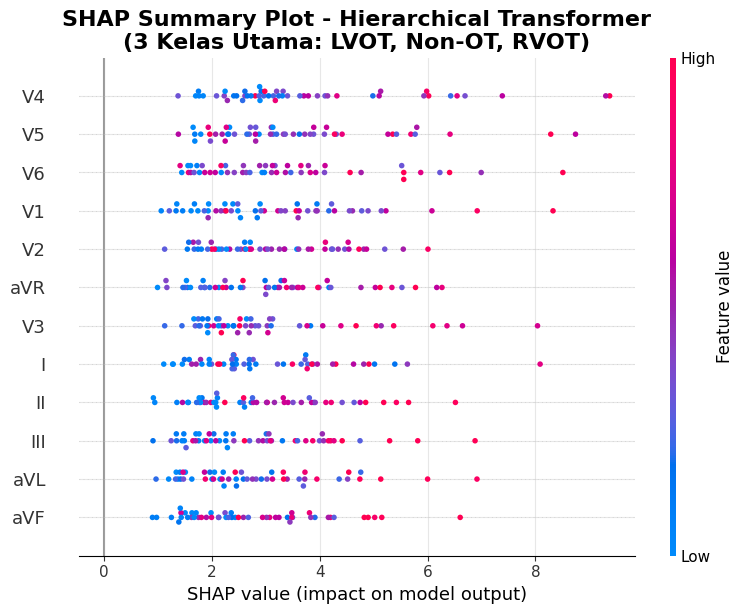

In [11]:
import shap

print("=" * 70)
print(f"🔍 SHAP EXPLAINABILITY ANALYSIS ({best_final})")
print("=" * 70)

np.random.seed(SEED)
bg_idx = np.random.choice(len(X_train_final), size=min(100, len(X_train_final)), replace=False)
background = torch.FloatTensor(X_train_final[bg_idx]).to(DEVICE)

n_exp = min(50, len(X_test_scaled))
exp_idx = np.random.choice(len(X_test_scaled), size=n_exp, replace=False)
exp_data = torch.FloatTensor(X_test_scaled[exp_idx]).to(DEVICE)

print("\n⏳ Computing SHAP values (GradientExplainer)...")
best_final_model.eval()

try:
    explainer = shap.GradientExplainer(best_final_model, background)
    shap_values = explainer.shap_values(exp_data)
    if isinstance(shap_values, list):
        shap_vals = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        shap_vals = np.abs(shap_values)
    print("✅ SHAP computed successfully!")
except Exception as e:
    print(f"⚠️ SHAP GradientExplainer failed: {e}")
    print("   Falling back to manual gradient-based importance...")
    exp_data_grad = exp_data.clone().requires_grad_(True)
    out = best_final_model(exp_data_grad)
    out.sum().backward()
    shap_vals = np.abs(exp_data_grad.grad.cpu().numpy())
    print("✅ Gradient-based importance computed!")

if len(shap_vals.shape) == 4:
    shap_vals = shap_vals.mean(axis=-1)

lead_imp = shap_vals.mean(axis=(0, 2))
lead_imp_df = pd.DataFrame({"Lead": LEADS, "Importance": lead_imp}).sort_values("Importance", ascending=False)

print(f"\n{str("Lead"):<8} {str("Importance"):<12}")
print("─" * 20)
for _, row in lead_imp_df.iterrows():
    bar = "█" * int(row["Importance"] / lead_imp_df["Importance"].max() * 30)
    print(f"{row["Lead"]:<8} {row["Importance"]:<12.6f} {bar}")

print("\n📊 Generating SHAP Summary Plot...")
shap_vals_2d = shap_vals.sum(axis=2)
exp_data_np = exp_data.cpu().numpy()
features_2d = np.std(exp_data_np, axis=2)

fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals_2d, features=features_2d, feature_names=LEADS, show=False)
plt.title(f"SHAP Summary Plot - {best_final}\n(3 Kelas Utama: {", ".join(CLASS_NAMES)})",
          fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "shap_summary_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show(block=False)
plt.close()

---
## 11. Ringkasan & Penyimpanan Hasil Akhir

**Proses Sel ini:**
1. Menyimpan tabel metrik evaluasi final ke `final_test_results.csv`.
2. Menyimpan ranking bobot sadapan ke `lead_importance.csv`.
3. Menampilkan ringkasan komparasi performa model terbaik, skor F1, akurasi, dan sadapan top-3 hasil analisis SHAP.
4. Mengonfirmasi penyelesaian seluruh tahapan eksperimen Notebook 03 (Fine-Tuning).

In [12]:
print("\n" + "=" * 70)
print("💾 MENYIMPAN HASIL")
print("=" * 70)

# Simpan test results
test_rows = []
for mn in MODEL_NAMES:
    pm = all_final_test[mn]["patient_metrics"]
    test_rows.append({"model": mn, "level": "patient", **pm})
test_res_df = pd.DataFrame(test_rows)
test_res_df.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)
print(f"   ✅ Final test results: {OUTPUT_DIR / "final_test_results.csv"}")

lead_imp_df.to_csv(OUTPUT_DIR / "lead_importance.csv", index=False)
print(f"   ✅ Lead importance: {OUTPUT_DIR / "lead_importance.csv"}")

with open(OUTPUT_DIR / "best_configs.json", "w") as f:
    json.dump({mn: best_configs[mn]["params"] for mn in MODEL_NAMES}, f, indent=2)

print("\n" + "=" * 70)
print("📋 RINGKASAN NOTEBOOK 03: FINETUNING CNN-TRANSFORMER (3 KELAS)")
print("=" * 70)

print(f"""
🔬 PIPELINE:
   DATA DWT → 80/20 Split → GAN Augmentation (Train fold) → Grid Search (5-Fold CV Patient-Wise) 
   → Final Training (Best Config, All 80%) → Inference 20% Unseen (SEKALI) → SHAP

🏆 BEST MODEL: {best_final}
   F1-Score (Patient-Level): {all_final_test[best_final]["patient_metrics"]["f1"]:.3f}
   Accuracy (Patient-Level): {all_final_test[best_final]["patient_metrics"]["accuracy"]:.3f}

🔍 SHAP TOP-3 LEADS: {", ".join(lead_imp_df.head(3)["Lead"].values)}

✅ Notebook 03 Selesai!
""")


💾 MENYIMPAN HASIL
   ✅ Final test results: finetune_results/final_test_results.csv
   ✅ Lead importance: finetune_results/lead_importance.csv

📋 RINGKASAN NOTEBOOK 03: FINETUNING CNN-TRANSFORMER (3 KELAS)

🔬 PIPELINE:
   DATA DWT → 80/20 Split → GAN Augmentation (Train fold) → Grid Search (5-Fold CV Patient-Wise) 
   → Final Training (Best Config, All 80%) → Inference 20% Unseen (SEKALI) → SHAP

🏆 BEST MODEL: Hierarchical Transformer
   F1-Score (Patient-Level): 0.725
   Accuracy (Patient-Level): 0.712

🔍 SHAP TOP-3 LEADS: V4, V5, V6

✅ Notebook 03 Selesai!

